In [1]:
import numpy as np
import matplotlib.pyplot as plt
import causal_gym as cgym
from causal_gym.envs.highway_single_step import HighwaySingleStepPCH
from causal_gym.core import Task

### Set up environment and demo functions

In the single step Highway environment, the observed covariate is the velocity of the front car Z,
and the ego velocity is the action X; the latents are its tail light indicator L and a weather condition
U. W means if the car to ego car's left is braking or not. 

The problem set up is that the expert policy can see the tail light of front cars and its velocity.
Thus it can always make the right decision in accelerating or breaking. However, for the imitator, 
it cannot see the tail light of front car. Instead, it can use W, whether the left car is braking, as 
an alternative source of the information to help it make the right decisions.

In [2]:
pch = HighwaySingleStepPCH(task=Task(learning_regime='cool'))
graph = pch.get_graph
graph

In [3]:
def show_obs(obs, info):
    print('Observation of current state')
    print('X (velocity of driving car):\t\t', obs['x'])
    print('Z (velocity of front vehicle):\t\t', obs['z'])
    print('W (if car to the left is braking):\t', obs['w'])

In [4]:
def show_frame(frame):
    plt.imshow(frame)
    plt.axis('off')
    plt.show()

### Display observation and render frame

Observation of current state
X (velocity of driving car):		 25.0
Z (velocity of front vehicle):		 21.80711915997225
W (if car to the left is braking):	 0


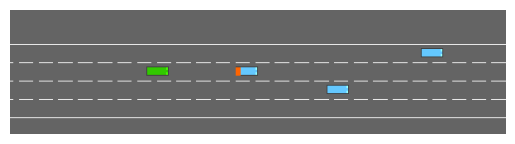

In [5]:
obs, info = pch.reset()
show_obs(obs, info)
show_frame(pch.render())

### SEE action taken by behavioral policy

Action observed:			 FASTER
Observation of current state
X (velocity of driving car):		 29.1455588268693
Z (velocity of front vehicle):		 30.0
W (if car to the left is braking):	 0


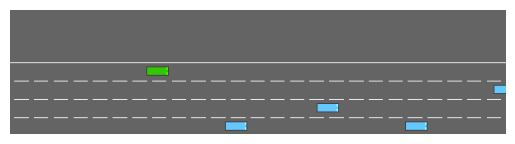

In [6]:
pch.reset()
obs, _, _, _, info = pch.see()
print('Action observed:\t\t\t', pch.env._meta_actions.ACTIONS_LONGI[info['natural_action']])
show_obs(obs, info)
show_frame(pch.render())

### DO intervention on X

Action taken:				 SLOWER
Observation of current state
X (velocity of driving car):		 20.8544411731307
Z (velocity of front vehicle):		 30.0
W (if car to the left is braking):	 0


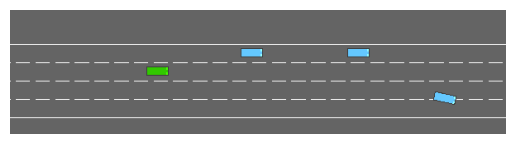

In [7]:
action = 0
pch.reset()
obs, _, _, _, info = pch.do(lambda x: action)
print('Action taken:\t\t\t\t', pch.env._meta_actions.ACTIONS_LONGI[action])
show_obs(obs, info)
show_frame(pch.render())

### Raw output of obs and info

In [8]:
print('Raw output:')
pch.reset()

Raw output:


({'x': 25.0, 'z': 21.55362611391385, 'w': 1},
 {'u': 1,
  'l': 1,
  'y': None,
  'env_obs': array([[ 1.        ,  0.8947537 ,  0.75      ,  0.3125    ,  0.        ],
         [ 1.        ,  0.10241093,  0.        , -0.04307967,  0.        ],
         [ 1.        ,  0.20298864, -0.25      , -0.03022999,  0.        ],
         [ 1.        ,  0.314832  , -0.25      , -0.03360315,  0.        ],
         [ 1.        ,  0.41917118,  0.        , -0.04303301,  0.        ]],
        dtype=float32),
  'env_info': {'speed': 25,
   'crashed': False,
   'action': 0,
   'rewards': {'collision_reward': 0.0,
    'right_lane_reward': 1.0,
    'high_speed_reward': 0.5,
    'on_road_reward': 1.0}}})

### Full single-step simulation using behavioral policy

Before:
Observation of current state
X (velocity of driving car):		 25.0
Z (velocity of front vehicle):		 30.0
W (if car to the left is braking):	 0
After:
Observation of current state
X (velocity of driving car):		 29.1455588268693
Z (velocity of front vehicle):		 30.0
W (if car to the left is braking):	 0


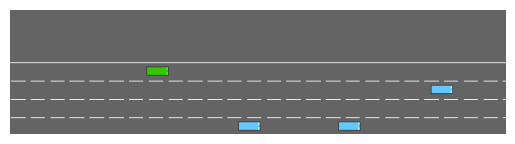

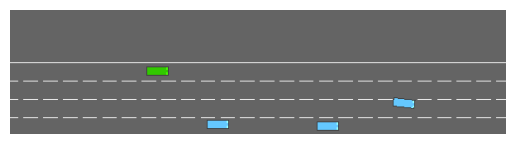

Action observed:	 FASTER


In [10]:
obs, info = pch.reset()
print('Before:')
show_obs(obs, info)
before = pch.render()

obs, _, _, _, info = pch.see()
print('After:')
show_obs(obs, info)
after = pch.render()

show_frame(before)
show_frame(after)
print('Action observed:\t', pch.env._meta_actions.ACTIONS_LONGI[info['natural_action']])